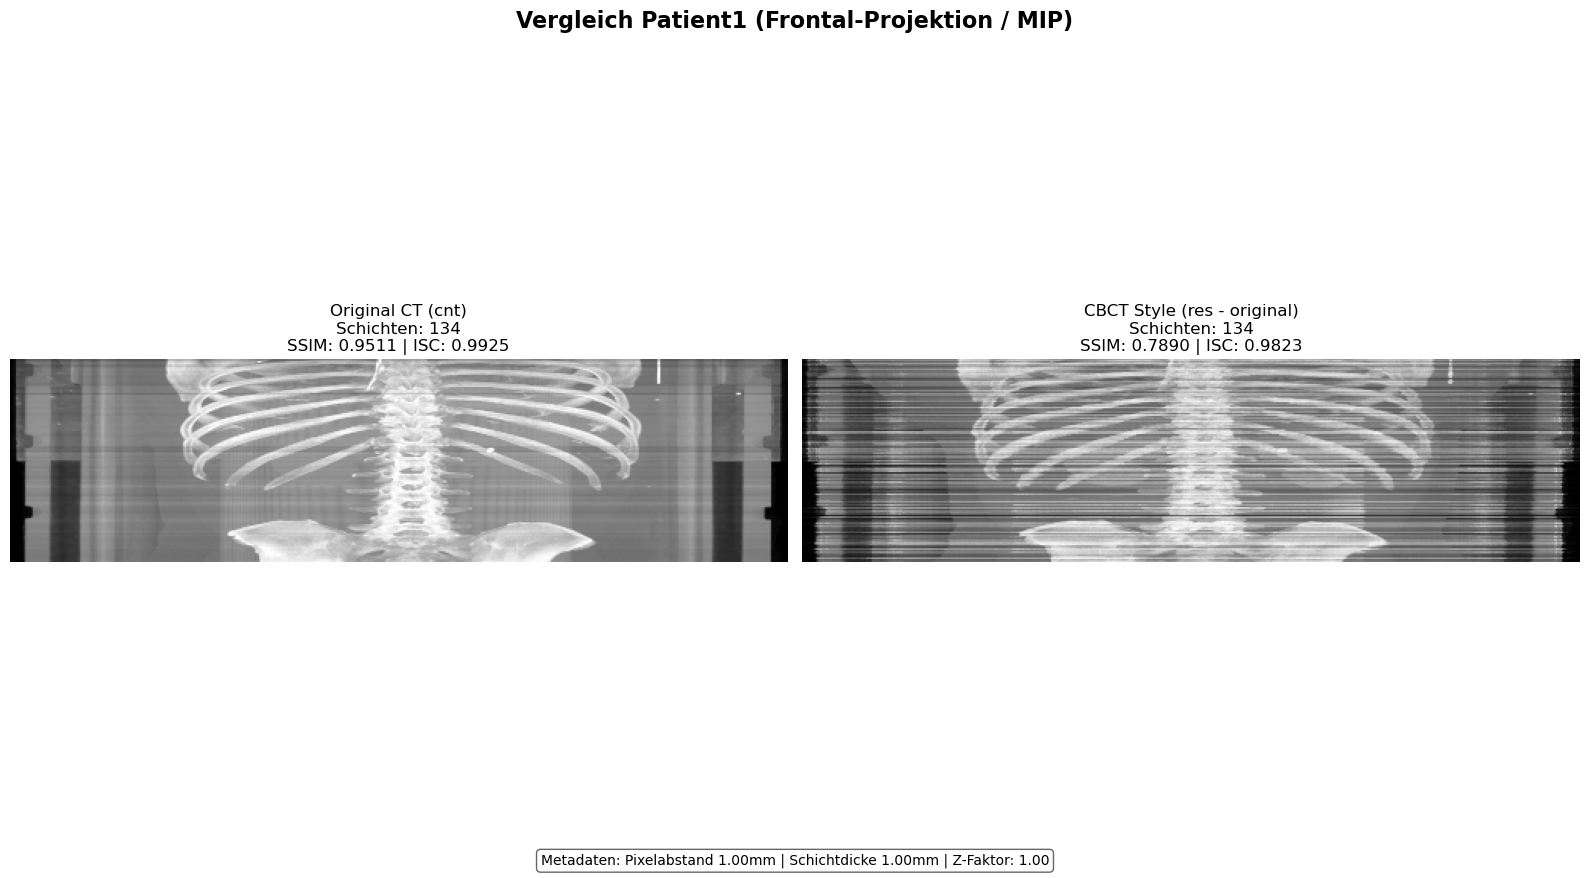

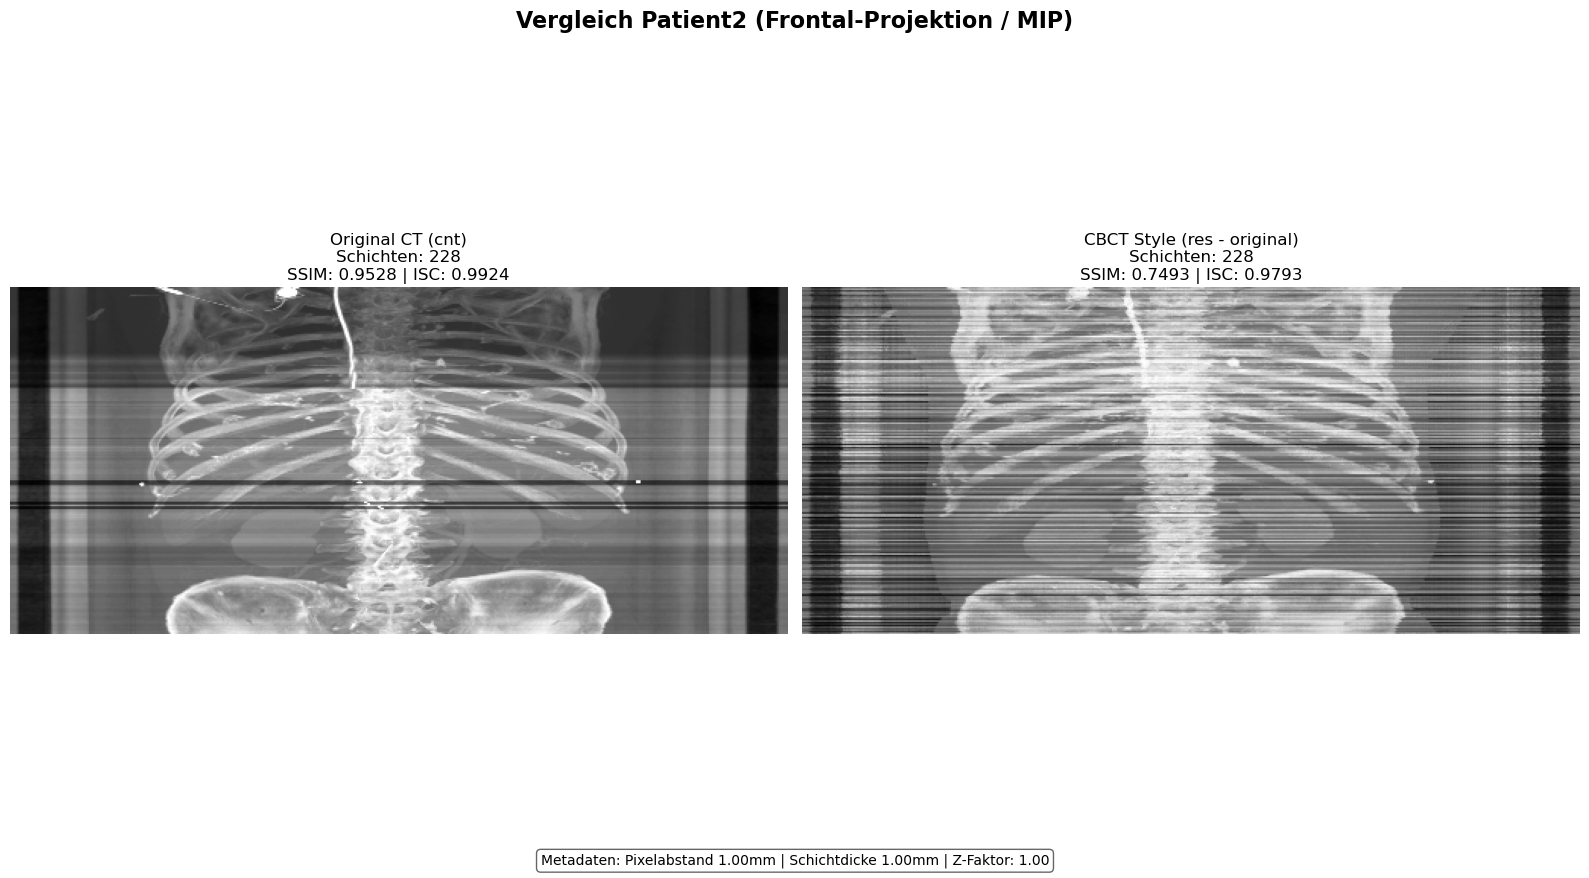

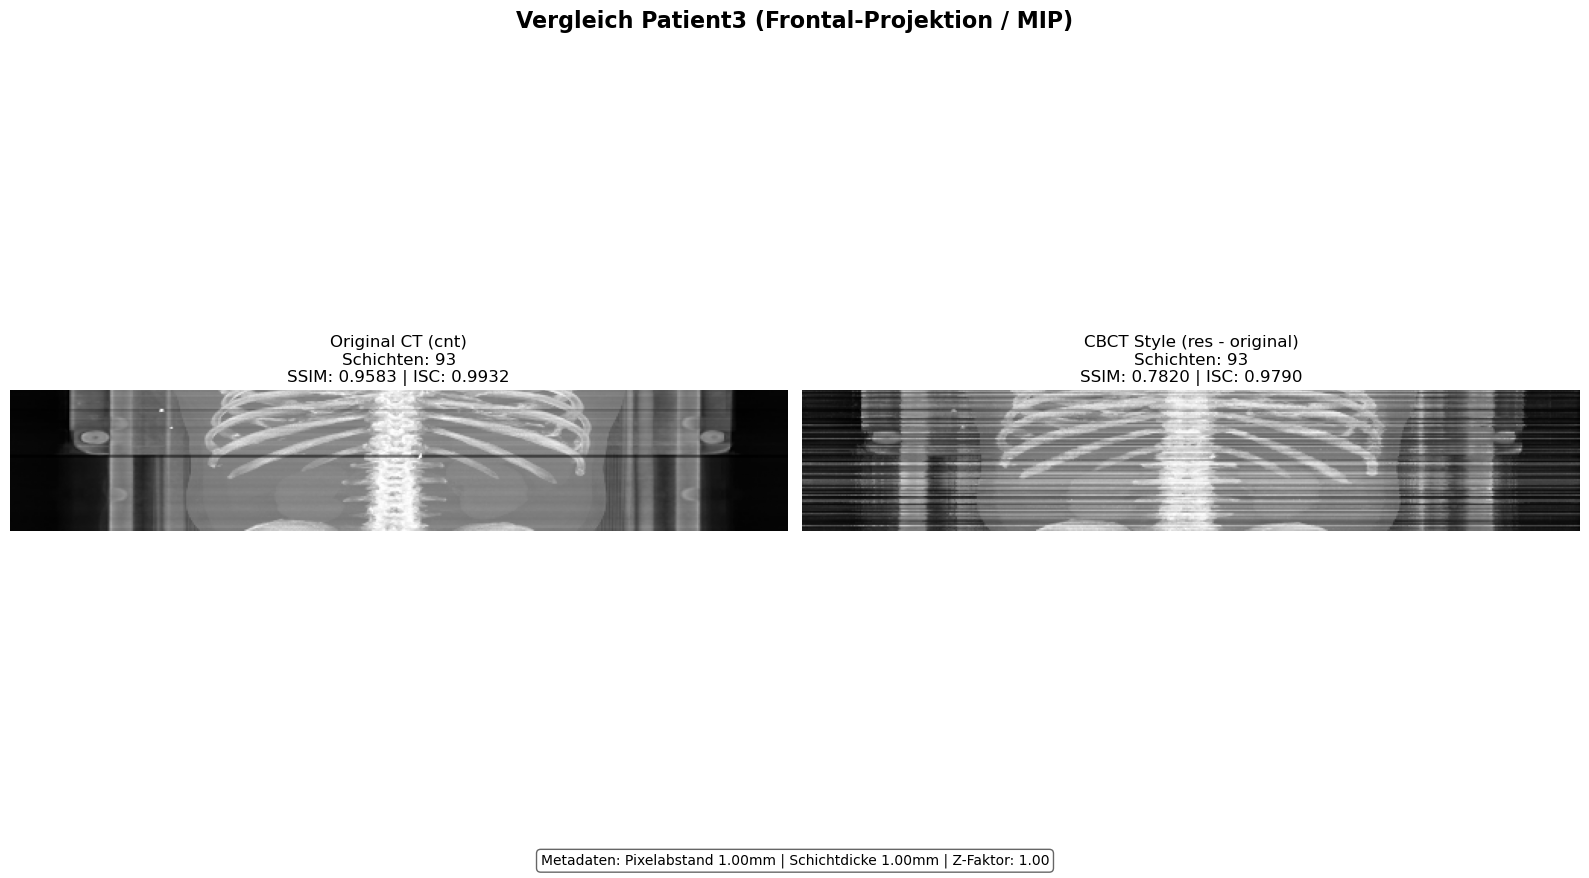

In [15]:
import pathlib
import pydicom
import cv2
import numpy as np
import re
import matplotlib.pyplot as plt
from skimage.metrics import structural_similarity as ssim

# --- HILFSFUNKTIONEN ---

def numerical_sort_key(path):
    numbers = re.findall(r'\d+', path.name)
    return int(numbers[-1]) if numbers else 0

def load_volume(folder_path):
    """Lädt alle Bilder eines Ordners (.dcm oder .png) zu einem 3D-Volumen."""
    files = sorted([f for f in folder_path.glob("*") if f.suffix.lower() in ['.dcm', '.png']], key=numerical_sort_key)
    if not files: return None, None, None
    
    volume = []
    spacing, thickness = [1.0, 1.0], 1.0
    
    for i, f in enumerate(files):
        if f.suffix.lower() == '.dcm':
            ds = pydicom.dcmread(str(f))
            if i == 0:
                spacing = ds.PixelSpacing if 'PixelSpacing' in ds else [1.0, 1.0]
                thickness = ds.SliceThickness if 'SliceThickness' in ds else 1.0
            img = ds.pixel_array.astype(float)
            img = (img - np.min(img)) / (np.max(img) - np.min(img) + 1e-5) * 255
            volume.append(img.astype(np.uint8))
        else:
            img = cv2.imread(str(f), cv2.IMREAD_GRAYSCALE)
            if img is not None:
                volume.append(img)
            
    return np.array(volume), spacing, thickness

def get_projection_and_metrics(volume, z_factor):
    """Erstellt eine Frontal-Projektion (MIP) und berechnet SSIM + Inter-slice Correlation."""
    if volume is None or len(volume) < 2: return None, 0.0, 0.0
    
    ssim_scores = []
    isc_scores = []
    
    for i in range(len(volume) - 1):
        img1 = volume[i]
        img2 = volume[i+1]
        
        # 1. Metrik: Structural Similarity Index (SSIM)
        s = ssim(img1, img2, data_range=255)
        ssim_scores.append(s)
        
        # 2. Metrik: Inter-slice Correlation (Pearson)
        # Wir flachen die 2D-Bilder zu 1D-Vektoren ab
        c = np.corrcoef(img1.ravel(), img2.ravel())[0, 1]
        isc_scores.append(c)
    
    mean_ssim = np.mean(ssim_scores)
    mean_isc = np.mean(isc_scores)
    
    # Optik: Maximum Intensity Projection (MIP)
    mip = np.max(volume, axis=1)
    
    # Anatomisch korrekte Skalierung
    new_h = int(mip.shape[0] * z_factor)
    mip_resized = cv2.resize(mip, (mip.shape[1], new_h), interpolation=cv2.INTER_CUBIC)
    
    return mip_resized, mean_ssim, mean_isc

# --- ANALYSE-LOOP FÜR PATIENTEN 1, 2, 3 ---

HAUPT_ORDNER = "Patienten" # Pfad zu deinem Hauptverzeichnis hier anpassen

for p_num in [1, 2, 3]:
    p_id = f"Patient{p_num}"
    p_path = pathlib.Path(HAUPT_ORDNER) / p_id
    
    if not p_path.exists():
        print(f"Überspringe {p_id}: Ordner existiert nicht.")
        continue

    # Volumina laden
    vol_cnt, spacing, thick = load_volume(p_path / f"{p_id}_cnt")
    vol_res, _, _ = load_volume(p_path / f"{p_id}_res")
    
    if vol_cnt is None or vol_res is None or len(vol_cnt) == 0:
        print(f"Fehler bei {p_id}: Daten unvollständig.")
        continue
        
    z_factor = thick / spacing[0]
    
    # Projektionen und beide Metriken berechnen
    mip_cnt, ssim_cnt, isc_cnt = get_projection_and_metrics(vol_cnt, z_factor)
    mip_res, ssim_res, isc_res = get_projection_and_metrics(vol_res, z_factor)
    
    # VISUALISIERUNG
    fig, axes = plt.subplots(1, 2, figsize=(16, 9))
    fig.suptitle(f"Vergleich {p_id} (Frontal-Projektion / MIP)", fontsize=16, fontweight='bold')

    # Linkes Bild: CT
    axes[0].imshow(mip_cnt, cmap='gray')
    axes[0].set_title(
        f"Original CT (cnt)\nSchichten: {len(vol_cnt)}\n"
        f"SSIM: {ssim_cnt:.4f} | ISC: {isc_cnt:.4f}", 
        fontsize=12
    )
    axes[0].axis('off')

    # Rechtes Bild: CBCT Style
    axes[1].imshow(mip_res, cmap='gray')
    axes[1].set_title(
        f"CBCT Style (res - original)\nSchichten: {len(vol_res)}\n"
        f"SSIM: {ssim_res:.4f} | ISC: {isc_res:.4f}", 
        fontsize=12
    )
    axes[1].axis('off')

    # Zusatzinfo Box
    info_box = f"Metadaten: Pixelabstand {spacing[0]:.2f}mm | Schichtdicke {thick:.2f}mm | Z-Faktor: {z_factor:.2f}"
    plt.figtext(0.5, 0.03, info_box, ha="center", fontsize=10, bbox={"facecolor":"white", "alpha":0.6, "boxstyle":"round"})
    
    plt.tight_layout(rect=[0, 0.05, 1, 0.95])
    plt.show()